In [199]:
%pip install -q numpy control sympy scipy matplotlib

import control as ctrl
import numpy as np
import sympy as sym
import scipy as sp
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


![script_1](./script/1.jpeg)


# Utils

In [200]:
from IPython.display import display, Markdown, Math
from typing import Dict, Union, Tuple, Any, List
from dataclasses import dataclass
import numpy.typing as npt

@dataclass
class SystemData:
	"""Data structure for transfer function analysis results."""
	tf: ctrl.TransferFunction
	step_time: npt.NDArray[np.floating]
	step_response: npt.NDArray[np.floating]
	step_info: Dict[str, float]
	poles: npt.NDArray[np.complexfloating]
	zeros: npt.NDArray[np.complexfloating]
	dc_gain: float
	omega: npt.NDArray[np.floating]
	magnitude: npt.NDArray[np.floating]
	phase: npt.NDArray[np.floating]
	bandwidth: float
	color: str

def _calculate_system_data(tf: ctrl.TransferFunction, color: str, time_vector: npt.NDArray[np.floating]) -> SystemData:
	"""Calculate all analysis data for a single transfer function."""
	# Calculate step response
	t_step, y_step = ctrl.step_response(tf, time_vector)
	
	# Get poles and zeros
	poles = ctrl.poles(tf)
	zeros = ctrl.zeros(tf)
	
	# Calculate step response characteristics manually from the data
	step_info = _calculate_step_response_metrics(t_step, y_step)
	
	# Calculate DC gain from step response final value
	dc_gain = step_info['SteadyStateValue']
	
	# Calculate frequency response
	frequency = np.logspace(-2, 2, 1000)
	mag, phase, omega = ctrl.bode_plot(tf, omega=frequency, dB=True, Hz=False, deg=True, plot=False)
	
	# Find bandwidth using the practical DC gain
	mag_db = 20*np.log10(mag)
	
	# Check if DC gain is valid for bandwidth calculation
	if np.isinf(dc_gain) or np.isnan(dc_gain) or dc_gain <= 0:
		# For problematic DC gains, use low-frequency magnitude as reference
		low_freq_mag_db = mag_db[0]
		target_db = low_freq_mag_db - 3
		
		# Find the first frequency where magnitude drops below target
		idx_3db = np.argmax(mag_db < target_db)
		if idx_3db == 0:  # If no frequency found, use a default
			bandwidth = omega[-1]  # Use highest frequency as fallback
		else:
			bandwidth = omega[idx_3db]
	else:
		# Normal bandwidth calculation using practical DC gain
		dc_gain_db = 20*np.log10(abs(dc_gain))
		target_db = dc_gain_db - 3
		idx_3db = np.argmin(np.abs(mag_db - target_db))
		bandwidth = omega[idx_3db]
	
	return SystemData(
		tf=tf,
		step_time=t_step,
		step_response=y_step,
		step_info=step_info,
		poles=poles,
		zeros=zeros,
		dc_gain=dc_gain,
		omega=omega,
		magnitude=mag,
		phase=phase,
		bandwidth=bandwidth,
		color=color
	)

def _calculate_step_response_metrics(t: npt.NDArray[np.floating], y: npt.NDArray[np.floating]) -> Dict[str, float]:
	"""Calculate step response metrics manually from time and output data."""
	metrics = {}
	
	# Steady-state value (final value)
	steady_state = y[-1]
	metrics['SteadyStateValue'] = steady_state
	
	# Handle cases where steady state is 0 or very small
	if abs(steady_state) < 1e-10:
		metrics['RiseTime'] = float('nan')
		metrics['SettlingTime'] = float('nan')
		metrics['Peak'] = float('nan')
		metrics['PeakTime'] = float('nan')
		metrics['Overshoot'] = float('nan')
		metrics['Undershoot'] = float('nan')
		return metrics
	
	# Calculate rise time (10% to 90% of steady state)
	target_10 = 0.1 * steady_state
	target_90 = 0.9 * steady_state
	
	# Find indices where response crosses 10% and 90% thresholds
	idx_10 = np.argmax(y >= target_10) if steady_state > 0 else np.argmax(y <= target_10)
	idx_90 = np.argmax(y >= target_90) if steady_state > 0 else np.argmax(y <= target_90)
	
	if idx_10 < idx_90:
		metrics['RiseTime'] = t[idx_90] - t[idx_10]
	else:
		metrics['RiseTime'] = float('nan')
	
	# Calculate settling time (within 2% of steady state)
	tolerance = 0.02 * abs(steady_state)
	settling_band = np.abs(y - steady_state) <= tolerance
	
	# Find the last time the response was outside the settling band
	if np.any(~settling_band):
		last_outside = np.where(~settling_band)[0][-1]
		if last_outside < len(t) - 1:
			metrics['SettlingTime'] = t[last_outside + 1]
		else:
			metrics['SettlingTime'] = t[-1]
	else:
		metrics['SettlingTime'] = 0.0
	
	# Calculate peak value and time
	if steady_state > 0:
		peak_idx = np.argmax(y)
	else:
		peak_idx = np.argmin(y)
	
	peak_value = y[peak_idx]
	metrics['Peak'] = peak_value
	metrics['PeakTime'] = t[peak_idx]
	
	# Calculate overshoot percentage
	if steady_state != 0:
		overshoot = ((peak_value - steady_state) / steady_state) * 100
		metrics['Overshoot'] = max(0, overshoot)  # Only positive overshoot
		metrics['Undershoot'] = max(0, -overshoot)  # Only positive undershoot
	else:
		metrics['Overshoot'] = float('nan')
		metrics['Undershoot'] = float('nan')
	
	return metrics

def _plot_step_response(systems_data: Dict[str, SystemData], detailed: bool) -> None:
	"""Plot step response comparison for all systems."""
	ax1 = plt.subplot(4, 1, 1)
	
	# Plot all systems
	for name, data in systems_data.items():
		plt.plot(data.step_time, data.step_response, 
				color=data.color, linewidth=2, label=f'{name} - Step Response')
		
		# Add markers for key points if detailed or single system
		if detailed or len(systems_data) == 1:
			step_info = data.step_info
			
			# Add horizontal line for steady state value
			plt.axhline(y=step_info['SteadyStateValue'], color=data.color, 
					   linestyle='--', alpha=0.5, 
					   label=f'{name} - Steady State = {step_info["SteadyStateValue"]:.4f}')
			
			# Mark rise time
			if 'RiseTime' in step_info:
				rise_time = step_info['RiseTime']
				plt.axvline(x=rise_time, color=data.color, linestyle=':', alpha=0.7,
						   label=f'{name} - Rise Time = {rise_time:.3f}s')
			
			# Mark peak and overshoot
			if 'Peak' in step_info and 'PeakTime' in step_info:
				peak = step_info['Peak']
				peak_time = step_info['PeakTime']
				plt.plot(peak_time, peak, 'o', color=data.color, markersize=6,
						label=f'{name} - Peak = {peak:.4f}')
	
	plt.grid(True, alpha=0.3)
	plt.xlabel('Time (s)')
	plt.ylabel('Amplitude')
	plt.title('Step Response Comparison' if len(systems_data) > 1 else 'Step Response Analysis', 
			  fontsize=14, fontweight='bold')
	plt.legend()

def _plot_bode_magnitude(systems_data: Dict[str, SystemData], detailed: bool) -> None:
	"""Plot Bode magnitude comparison for all systems."""
	ax2 = plt.subplot(4, 1, 2)
	
	# Plot all systems
	for name, data in systems_data.items():
		mag_db = 20*np.log10(data.magnitude)
		plt.semilogx(data.omega, mag_db, color=data.color, linewidth=2, label=f'{name}')
		
		# Mark bandwidth if detailed or single system
		if detailed or len(systems_data) == 1:
			bandwidth = data.bandwidth
			
			# Use practical DC gain from step response (should be finite)
			if data.dc_gain > 0:
				dc_gain_db = 20*np.log10(abs(data.dc_gain))
				plt.axvline(x=bandwidth, color=data.color, linestyle='--', alpha=0.5,
						   label=f'{name} - BW = {bandwidth:.2f} rad/s')
				plt.plot(bandwidth, dc_gain_db - 3, 'o', color=data.color, markersize=6)
			else:
				# Fallback: use magnitude at bandwidth frequency
				idx_bw = np.argmin(np.abs(data.omega - bandwidth))
				mag_at_bw = mag_db[idx_bw]
				plt.axvline(x=bandwidth, color=data.color, linestyle='--', alpha=0.5,
						   label=f'{name} - BW = {bandwidth:.2f} rad/s')
				plt.plot(bandwidth, mag_at_bw, 'o', color=data.color, markersize=6)
	
	plt.grid(True, alpha=0.3)
	plt.xlabel('Frequency (rad/s)')
	plt.ylabel('Magnitude (dB)')
	plt.title('Bode Plot - Magnitude Comparison' if len(systems_data) > 1 else 'Bode Plot - Magnitude',
			  fontsize=14, fontweight='bold')
	plt.legend()

def _plot_bode_phase(systems_data: Dict[str, SystemData], detailed: bool) -> None:
	"""Plot Bode phase comparison for all systems."""
	ax3 = plt.subplot(4, 1, 3)
	
	# Plot all systems
	for name, data in systems_data.items():
		phase_deg = data.phase * 180/np.pi
		plt.semilogx(data.omega, phase_deg, color=data.color, linewidth=2, label=f'{name}')
		
		# Mark phase at bandwidth if detailed or single system
		if detailed or len(systems_data) == 1:
			bandwidth = data.bandwidth
			# Find phase at bandwidth
			idx_3db = np.argmin(np.abs(data.omega - bandwidth))
			phase_at_bw = phase_deg[idx_3db]
			plt.axvline(x=bandwidth, color=data.color, linestyle='--', alpha=0.5)
			plt.plot(bandwidth, phase_at_bw, 'o', color=data.color, markersize=6,
					label=f'{name} - Phase at BW = {phase_at_bw:.1f}°')
	
	plt.grid(True, alpha=0.3)
	plt.xlabel('Frequency (rad/s)')
	plt.ylabel('Phase (deg)')
	plt.title('Bode Plot - Phase Comparison' if len(systems_data) > 1 else 'Bode Plot - Phase',
			  fontsize=14, fontweight='bold')
	plt.legend()

def _plot_pole_zero(systems_data: Dict[str, SystemData]) -> None:
	"""Plot pole-zero comparison for all systems."""
	ax4 = plt.subplot(4, 1, 4)
	
	# Plot unit circle
	theta = np.linspace(0, 2*np.pi, 100)
	plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, label='Unit Circle')
	
	# Plot poles and zeros for all systems
	for name, data in systems_data.items():
		poles = data.poles
		zeros = data.zeros
		color = data.color
		
		# Plot poles
		if len(poles) > 0:
			pole_real = np.real(poles)
			pole_imag = np.imag(poles)
			plt.plot(pole_real, pole_imag, 'x', color=color, markersize=12, markeredgewidth=3, 
					label=f'{name} - Poles')
		
		# Plot zeros
		if len(zeros) > 0:
			zero_real = np.real(zeros)
			zero_imag = np.imag(zeros)
			plt.plot(zero_real, zero_imag, 'o', color=color, markersize=12, markeredgewidth=3,
					label=f'{name} - Zeros')
	
	plt.grid(True, alpha=0.3)
	plt.xlabel('Real Part')
	plt.ylabel('Imaginary Part')
	plt.title('Pole-Zero Plot Comparison' if len(systems_data) > 1 else 'Pole-Zero Plot',
			  fontsize=14, fontweight='bold')
	plt.legend()
	plt.axis('equal')

def _generate_step_response_table(systems_data: Dict[str, SystemData]) -> str:
	"""Generate step response comparison table."""
	# Create comparison table header
	header = "| Parameter | Unit |"
	separator = "|-----------|------|"
	for name in systems_data.keys():
		header += f" {name} |"
		separator += "------|"
	
	step_table = header + "\n" + separator + "\n"
	
	# Add rows for each parameter
	parameters = [
		('Rise Time', 'RiseTime', 's', '.4f'),
		('Settling Time', 'SettlingTime', 's', '.4f'),
		('Peak Value', 'Peak', '-', '.4f'),
		('Peak Time', 'PeakTime', 's', '.4f'),
		('Overshoot', 'Overshoot', '%', '.2f'),
		('Undershoot', 'Undershoot', '%', '.2f'),
		('Steady State Value', 'SteadyStateValue', '-', '.4f'),
		('DC Gain (from step response)', 'DC Gain', '-', '.4f'),
		('DC Gain (dB)', 'DC Gain (dB)', 'dB', '.2f')
	]
	
	for param_name, param_key, unit, fmt in parameters:
		row = f"| **{param_name}** | {unit} |"
		for name, data in systems_data.items():
			if param_key == 'DC Gain':
				value = data.dc_gain
				row += f" {value:{fmt}} |"
			elif param_key == 'DC Gain (dB)':
				if data.dc_gain > 0:
					value = 20*np.log10(abs(data.dc_gain))
					row += f" {value:{fmt}} |"
				else:
					row += " N/A |"
			else:
				value = data.step_info.get(param_key, 'N/A')
				if value != 'N/A':
					row += f" {value:{fmt}} |"
				else:
					row += " N/A |"
		step_table += row + "\n"
	
	return step_table

def _generate_transfer_function_table(systems_data: Dict[str, SystemData]) -> str:
	"""Generate transfer function properties comparison table."""
	tf_header = "| Property |"
	tf_separator = "|----------|"
	for name in systems_data.keys():
		tf_header += f" {name} |"
		tf_separator += "------|"
	
	tf_table = tf_header + "\n" + tf_separator + "\n"
	
	# Add system properties
	properties = [
		('System Order', lambda data: len(data.poles)),
		('Number of Zeros', lambda data: len(data.zeros)),
		('Bandwidth (-3dB)', lambda data: f"{data.bandwidth:.3f} rad/s"),
		('System Type', lambda data: 'Proper' if len(data.poles) >= len(data.zeros) else 'Improper'),
		('Stability', lambda data: 'STABLE' if np.all(np.real(data.poles) < 0) else 'UNSTABLE')
	]
	
	for prop_name, prop_func in properties:
		row = f"| **{prop_name}** |"
		for name, data in systems_data.items():
			row += f" {prop_func(data)} |"
		tf_table += row + "\n"
	
	return tf_table

def _generate_poles_table(systems_data: Dict[str, SystemData]) -> str:
	"""Generate poles comparison table."""
	# Find maximum number of poles across all systems
	max_poles = max(len(data.poles) for data in systems_data.values())
	
	if max_poles == 0:
		return ""
	
	poles_header = "| Pole |"
	poles_separator = "|------|"
	for name in systems_data.keys():
		poles_header += f" {name} (Real) | {name} (Imag) | {name} (Mag) |"
		poles_separator += "------|------|------|"
	
	poles_table = poles_header + "\n" + poles_separator + "\n"
	
	for i in range(max_poles):
		row = f"| p{i+1} |"
		for name, data in systems_data.items():
			if i < len(data.poles):
				pole = data.poles[i]
				real_part = np.real(pole)
				imag_part = np.imag(pole)
				magnitude = np.abs(pole)
				row += f" {real_part:.3f} | {imag_part:.3f} | {magnitude:.3f} |"
			else:
				row += " - | - | - |"
		poles_table += row + "\n"
	
	return poles_table

def _generate_zeros_table(systems_data: Dict[str, SystemData]) -> str:
	"""Generate zeros comparison table."""
	# Check if any system has zeros
	has_zeros = any(len(data.zeros) > 0 for data in systems_data.values())
	if not has_zeros:
		return ""
	
	max_zeros = max(len(data.zeros) for data in systems_data.values())
	
	zeros_header = "| Zero |"
	zeros_separator = "|------|"
	for name in systems_data.keys():
		zeros_header += f" {name} (Real) | {name} (Imag) | {name} (Mag) |"
		zeros_separator += "------|------|------|"
	
	zeros_table = zeros_header + "\n" + zeros_separator + "\n"
	
	for i in range(max_zeros):
		row = f"| z{i+1} |"
		for name, data in systems_data.items():
			if i < len(data.zeros):
				zero = data.zeros[i]
				real_part = np.real(zero)
				imag_part = np.imag(zero)
				magnitude = np.abs(zero)
				row += f" {real_part:.3f} | {imag_part:.3f} | {magnitude:.3f} |"
			else:
				row += " - | - | - |"
		zeros_table += row + "\n"
	
	return zeros_table

def _generate_simple_comparison_table(systems_data: Dict[str, SystemData]) -> str:
	"""Generate simplified comparison table."""
	# Create simple comparison table
	simple_header = "| Parameter | Unit |"
	simple_separator = "|-----------|------|"
	for name in systems_data.keys():
		simple_header += f" {name} |"
		simple_separator += "------|"
	
	simple_table = simple_header + "\n" + simple_separator + "\n"
	
	# Add key parameters
	simple_params = [
		('DC Gain (from step response)', lambda data: f"{data.dc_gain:.4f}"),
		('Rise Time', lambda data: f"{data.step_info.get('RiseTime', 'N/A'):.4f}" if data.step_info.get('RiseTime') != 'N/A' else 'N/A'),
		('Overshoot', lambda data: f"{data.step_info.get('Overshoot', 'N/A'):.2f}%" if data.step_info.get('Overshoot') != 'N/A' else 'N/A'),
		('Bandwidth (-3dB)', lambda data: f"{data.bandwidth:.3f}"),
		('Stability', lambda data: 'STABLE' if np.all(np.real(data.poles) < 0) else 'UNSTABLE')
	]
	
	units = ['-', 's', '%', 'rad/s', '-']
	
	for (param_name, param_func), unit in zip(simple_params, units):
		row = f"| **{param_name}** | {unit} |"
		for name, data in systems_data.items():
			row += f" {param_func(data)} |"
		simple_table += row + "\n"
	
	return simple_table

def _poly_to_string(coeffs: List[float], var: str = "s") -> str:
	"""Convert a list of coefficients into a polynomial string."""
	terms = []
	degree = len(coeffs) - 1
	for i, c in enumerate(coeffs):
		if c == 0:
			continue
		power = degree - i
		if power == 0:
			terms.append(f"{c}")
		elif power == 1:
			terms.append(f"{c}{var}")
		else:
			terms.append(f"{c}{var}^{power}")
	if not terms:
		return "0"
	return " + ".join(terms)

def _tf_to_latex(tf: ctrl.TransferFunction) -> str:
	"""Return LaTeX string of transfer function as a fraction."""
	# assuming SISO: first numerator and denominator
	num = tf.num[0][0]
	den = tf.den[0][0]
	num_str = _poly_to_string(num)
	den_str = _poly_to_string(den)
	latex = (
		r"$$"
		r"\frac{" + num_str.replace("*", "") + r"}{" + den_str.replace("*", "") + r"}"
		r"$$"
	)
	return latex

def _display_transfer_functions(systems_data: Dict[str, SystemData]) -> None:
	"""Display transfer functions in mathematical format."""
	display(Markdown("## Transfer Functions" if len(systems_data) > 1 else "## Transfer Function"))
	
	for name, data in systems_data.items():
		# Display system name
		display(Markdown(f"### {name}"))
		
		display(Math(_tf_to_latex(data.tf)))
		
		

def _display_detailed_analysis(systems_data: Dict[str, SystemData]) -> None:
	"""Display detailed analysis tables."""
	# Step Response Analysis
	display(Markdown("## Step Response Comparison" if len(systems_data) > 1 else "## Step Response Analysis"))
	step_table = _generate_step_response_table(systems_data)
	display(Markdown(step_table))
	
	# Transfer Function Analysis
	display(Markdown("## Transfer Function Comparison" if len(systems_data) > 1 else "## Transfer Function Analysis"))
	tf_table = _generate_transfer_function_table(systems_data)
	display(Markdown(tf_table))
	
	# Poles Analysis
	display(Markdown("## Poles Comparison" if len(systems_data) > 1 else "## Poles Analysis"))
	poles_table = _generate_poles_table(systems_data)
	if poles_table:
		display(Markdown(poles_table))
	
	# Zeros Analysis (if any system has zeros)
	zeros_table = _generate_zeros_table(systems_data)
	if zeros_table:
		display(Markdown("## Zeros Comparison" if len(systems_data) > 1 else "## Zeros Analysis"))
		display(Markdown(zeros_table))

def _display_simple_analysis(systems_data: Dict[str, SystemData]) -> None:
	"""Display simplified analysis table."""
	display(Markdown("## Key System Parameters Comparison" if len(systems_data) > 1 else "## Key System Parameters"))
	simple_table = _generate_simple_comparison_table(systems_data)
	display(Markdown(simple_table))

def analyze_and_plot_transfer_function(
	transfer_function: Union[ctrl.TransferFunction, Dict[str, ctrl.TransferFunction]], 
	detailed: bool = True
) -> None:
	"""
	Complete analysis and visualization of transfer function(s) including:
	- Step response with annotations
	- Bode plot with detailed information
	- Pole-zero plot
	
	Parameters:
	- transfer_function: Either a single ctrl.TransferFunction or a dict of {name: ctrl.TransferFunction}
	- detailed: If True, shows full analysis. If False, shows only key metrics.
	"""
	
	# Handle both single transfer function and dictionary of transfer functions
	if isinstance(transfer_function, dict):
		tf_dict: Dict[str, ctrl.TransferFunction] = transfer_function
	else:
		# Single transfer function - convert to dict
		tf_dict = {"System": transfer_function}
	
	# Define colors for multiple systems
	colors: List[str] = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
	
	# Calculate data for all systems
	systems_data: Dict[str, SystemData] = {}
	t: npt.NDArray[np.floating] = np.linspace(0, 5, 1000)
	
	for i, (name, tf) in enumerate(tf_dict.items()):
		color = colors[i % len(colors)]
		systems_data[name] = _calculate_system_data(tf, color, t)
	
	# Display transfer functions in mathematical format
	_display_transfer_functions(systems_data)
	
	# Create figure with vertical subplots
	fig = plt.figure(figsize=(12, 18))
	
	# Generate all plots
	_plot_step_response(systems_data, detailed)
	_plot_bode_magnitude(systems_data, detailed)
	_plot_bode_phase(systems_data, detailed)
	_plot_pole_zero(systems_data)
	
	plt.tight_layout()
	plt.show()
	
	# Display analysis tables
	if detailed:
		_display_detailed_analysis(systems_data)
	else:
		_display_simple_analysis(systems_data)


def create_pid(kp: float = 0.0, ki: float = 0.0, kd: float = 0.0) -> ctrl.TransferFunction:
	"""
	Create a PID controller transfer function in parallel form:
		C(s) = Kp + Ki/s + Kd*s
	Handles all combinations of nonzero terms cleanly. To avoid instabilities caused
	by precision

	Args:
		kp (float): Proportional gain
		ki (float): Integral gain
		kd (float): Derivative gain

	Returns:
		TransferFunction: PID controller transfer function
	"""
	if np.round(ki, 10) == 0.0 and np.round(kd, 10) == 0.0:
		# Only proportional
		return ctrl.TransferFunction([kp], [1])
	
	if np.round(kp, 10) == 0.0 and np.round(kd, 10) == 0.0:
		# Only integral
		return ctrl.TransferFunction([ki], [1, 0])
	
	if np.round(kp, 10) == 0.0 and np.round(ki, 10) == 0.0:
		# Only derivative
		return ctrl.TransferFunction([kd, 0], [1])
	
	if np.round(kd, 10) == 0.0:
		# PI
		num = [kp, ki]
		den = [1, 0]
		return ctrl.TransferFunction(num, den)
	
	if np.round(ki, 10) == 0.0:
		# PD
		num = [kd, kp]
		den = [1]
		return ctrl.TransferFunction(num, den)
	
	# Full PID
	num = [kd, kp, ki]
	den = [1, 0]
	return ctrl.TransferFunction(num, den)





## Transfer Function

### System

<IPython.core.display.Math object>

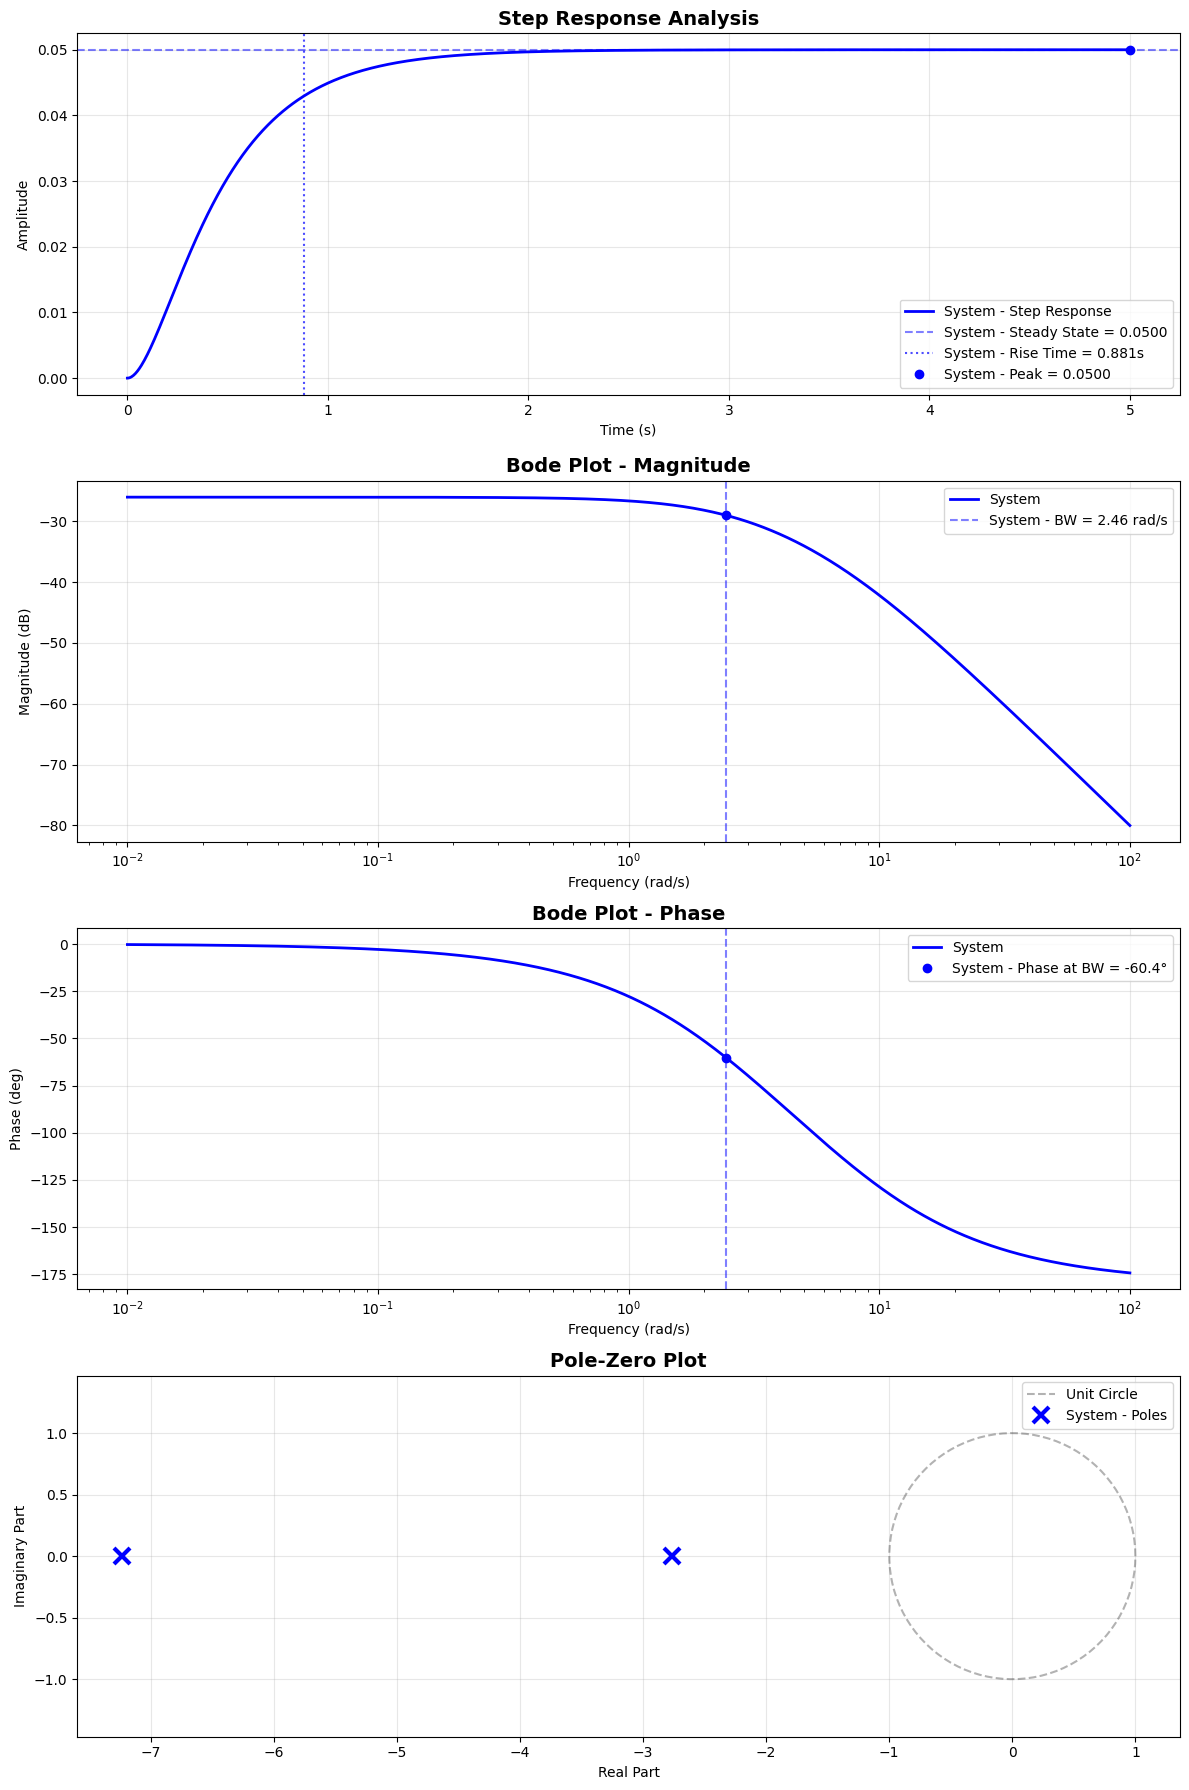

## Key System Parameters

| Parameter | Unit | System |
|-----------|------|------|
| **DC Gain (from step response)** | - | 0.0500 |
| **Rise Time** | s | 0.8809 |
| **Overshoot** | % | 0.00% |
| **Bandwidth (-3dB)** | rad/s | 2.457 |
| **Stability** | - | STABLE |


In [201]:
# Create open loop transfer function
open_loop_system = ctrl.TransferFunction([1], [1, 10, 20])

# Perform complete analysis function (detailed mode)
analyze_and_plot_transfer_function(open_loop_system, detailed=False)

![2](./script/2.jpeg)

# Controlador proporcional

## Estabilidade do Sistema com Ganho $K_p$

O sistema em malha aberta é:
$$
G(s) = \frac{1}{s^2 + 10s + 20}
$$

Com um controlador proporcional $C(s) = K_p$, a função de transferência em malha fechada é:
$$
T(s) = \frac{K_p G(s)}{1 + K_p G(s)}
$$

A equação característica é:
$$
1 + K_p G(s) = 0
$$

Ou seja:
$$
s^2 + 10s + (20 + K_p) = 0
$$

---

### Condições para estabilidade

Para um sistema de 2ª ordem:
$$
s^2 + a_1 s + a_0
$$

O sistema é estável se:
- $a_1 > 0$  
- $a_0 > 0$

Aqui $a_1 = 10 > 0$ sempre, e $a_0 = 20 + K_p$, então precisamos:
$$
20 + K_p > 0
$$

Ou seja:
$$
K_p > -20
$$


Então, como nos controladores o valor de $K_p$ comumente é usado como um valor positivo, não existe limite para $K_p$ para que o sistema seja estável.

## Transfer Functions

### Open Loop System

<IPython.core.display.Math object>

### Closed Loop System: Kp = 100

<IPython.core.display.Math object>

### Closed Loop System: Kp = 300

<IPython.core.display.Math object>

### Closed Loop System: Kp = 1000

<IPython.core.display.Math object>

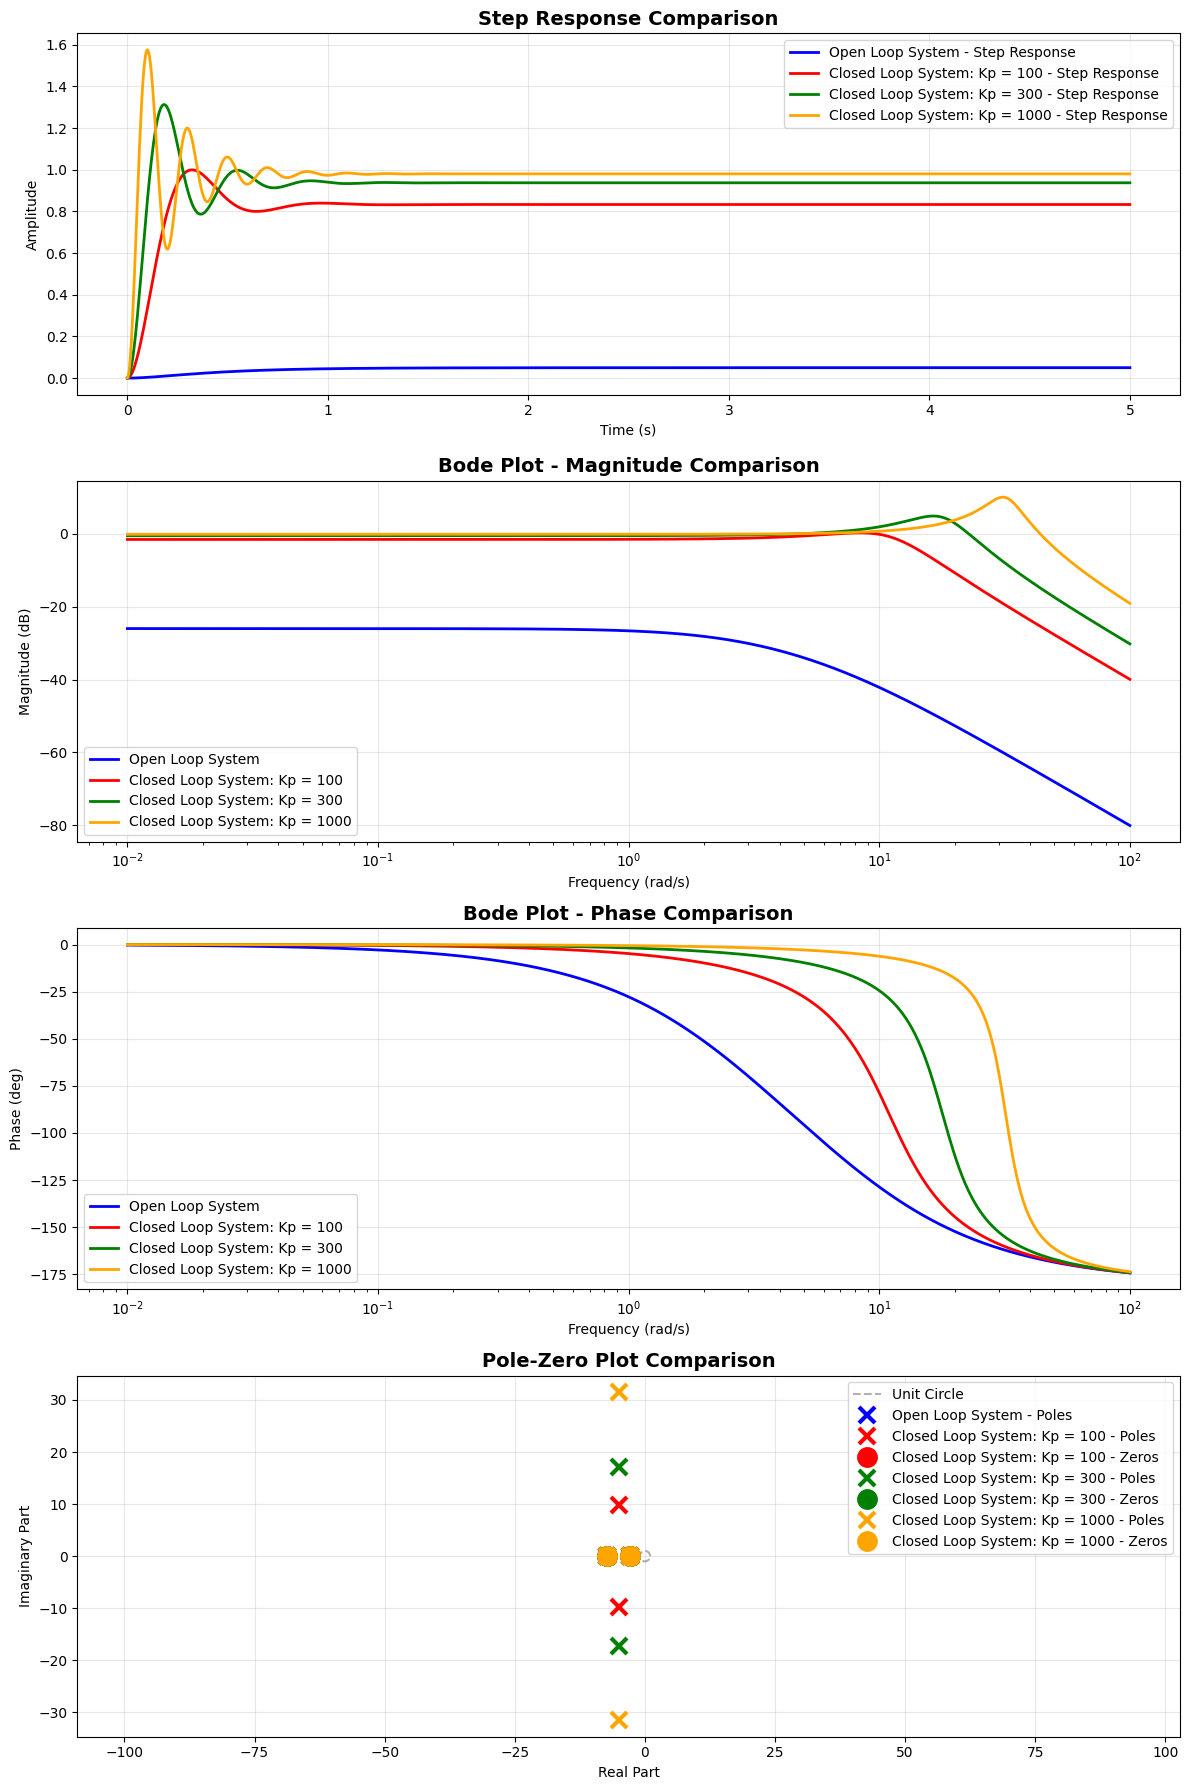

## Key System Parameters Comparison

| Parameter | Unit | Open Loop System | Closed Loop System: Kp = 100 | Closed Loop System: Kp = 300 | Closed Loop System: Kp = 1000 |
|-----------|------|------|------|------|------|
| **DC Gain (from step response)** | - | 0.0500 | 0.8333 | 0.9375 | 0.9804 |
| **Rise Time** | s | 0.8809 | 0.1451 | 0.0701 | 0.0400 |
| **Overshoot** | % | 0.00% | 19.95% | 40.04% | 60.77% |
| **Bandwidth (-3dB)** | rad/s | 2.457 | 14.426 | 26.268 | 48.718 |
| **Stability** | - | STABLE | STABLE | STABLE | STABLE |


In [202]:
# Closed loop response

controller_p_100  = create_pid(kp=100)
controller_p_300 = create_pid(kp=300)
controller_p_1000 = create_pid(kp=1000)

plant = open_loop_system

closed_loop_system_100 = controller_p_100 * plant / (1 + controller_p_100 * plant)
closed_loop_system_300 = controller_p_300 * plant / (1 + controller_p_300 * plant)
closed_loop_system_1000 = controller_p_1000 * plant / (1 + controller_p_1000 * plant)

analyze_and_plot_transfer_function(
	{ 
		"Open Loop System": plant,
		"Closed Loop System: Kp = 100": closed_loop_system_100,
		"Closed Loop System: Kp = 300": closed_loop_system_300,
		"Closed Loop System: Kp = 1000": closed_loop_system_1000
	},
	detailed=False
)

# Controlador proporcional derivativo


/Users/alejopm/eng/CLT/ifsc-control-systems/.venv/lib/python3.13/site-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


## Transfer Functions

### Open Loop System

<IPython.core.display.Math object>

### Closed Loop System: Kp = 300

<IPython.core.display.Math object>

### Closed Loop System: Kp = 300, Kd = 10

<IPython.core.display.Math object>

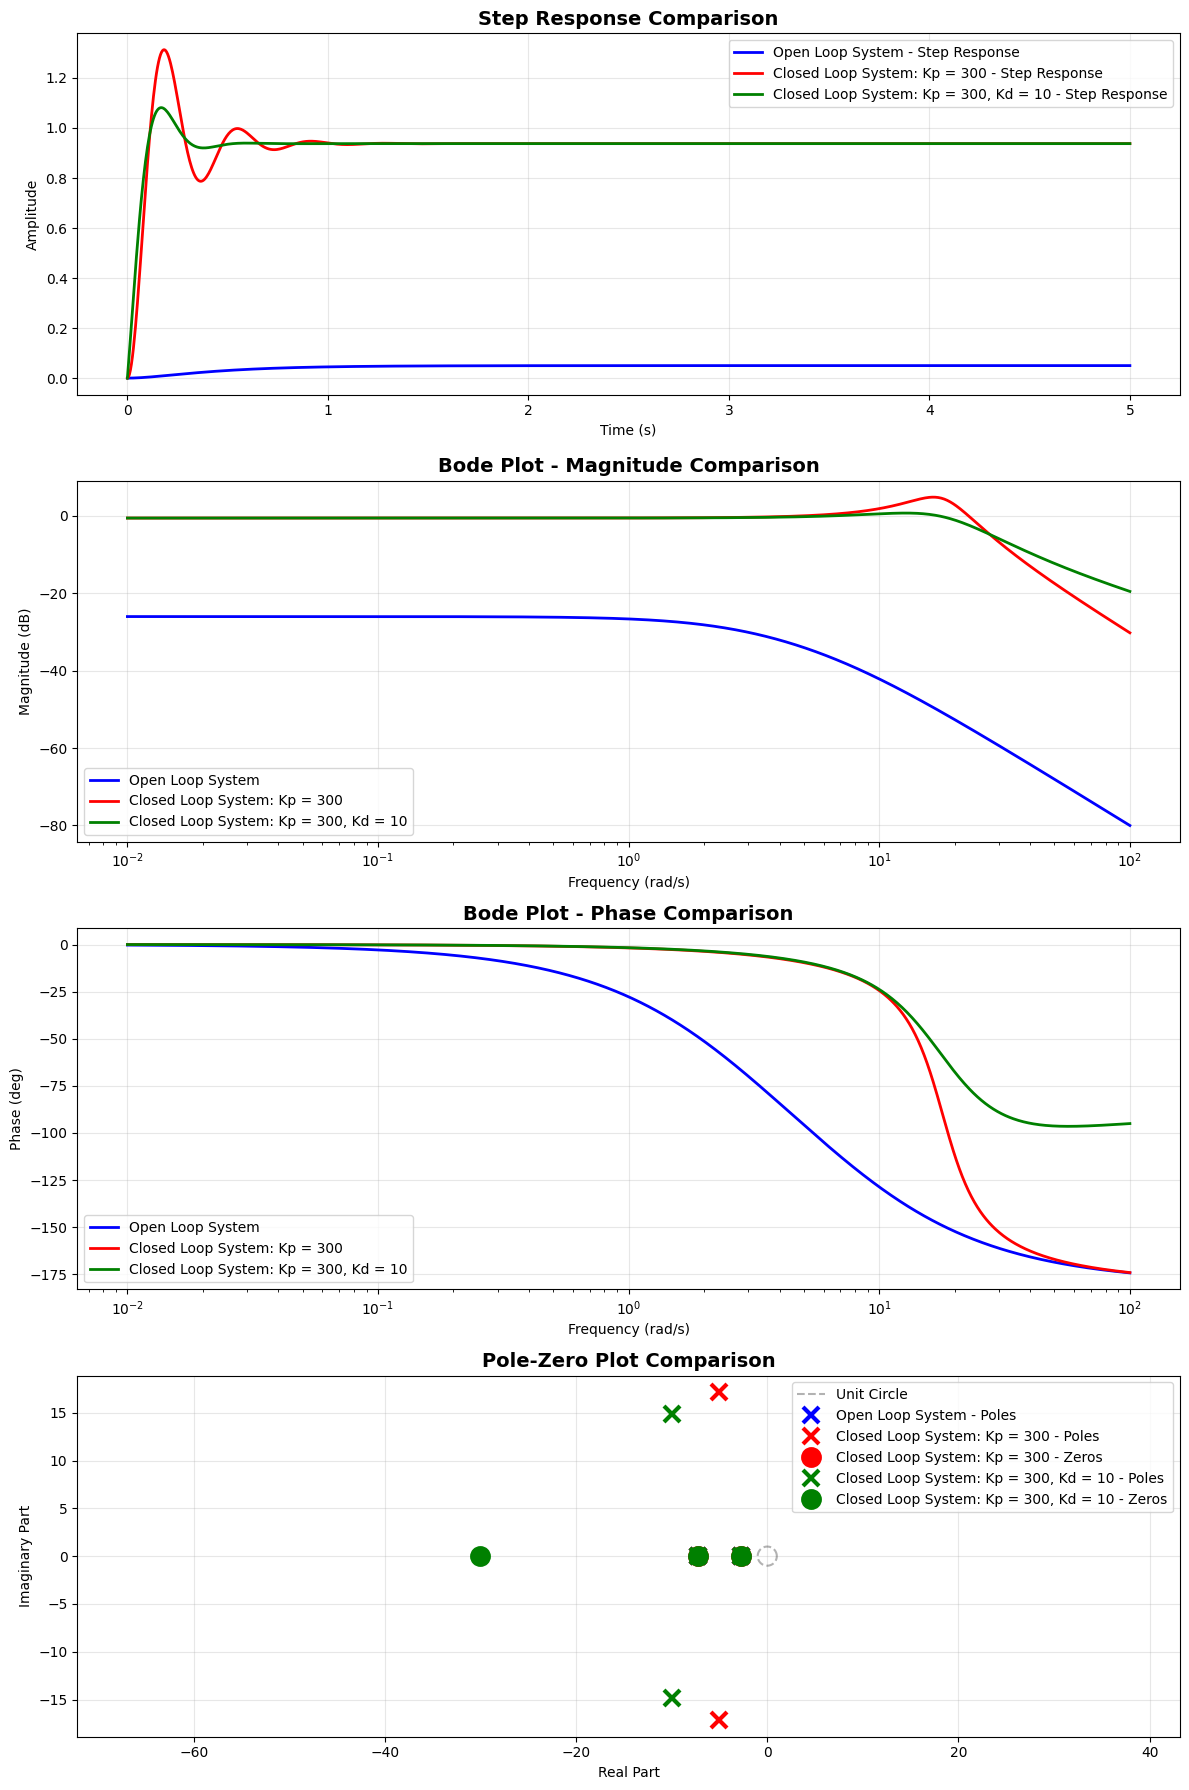

## Key System Parameters Comparison

| Parameter | Unit | Open Loop System | Closed Loop System: Kp = 300 | Closed Loop System: Kp = 300, Kd = 10 |
|-----------|------|------|------|------|
| **DC Gain (from step response)** | - | 0.0500 | 0.9375 | 0.9375 |
| **Rise Time** | s | 0.8809 | 0.0701 | 0.0801 |
| **Overshoot** | % | 0.00% | 40.04% | 15.34% |
| **Bandwidth (-3dB)** | rad/s | 2.457 | 26.268 | 25.084 |
| **Stability** | - | STABLE | STABLE | STABLE |


In [205]:
# Closed loop response

controller_p_300 = create_pid(kp=300)
controller_p_300_d_10 = create_pid(kp=300, kd=10)

plant = open_loop_system

closed_loop_system_300 = controller_p_300 * plant / (1 + controller_p_300 * plant)
closed_loop_system_300_d_10 = controller_p_300_d_10 * plant / (1 + controller_p_300_d_10 * plant)

analyze_and_plot_transfer_function(
	{ 
		"Open Loop System": plant,
		"Closed Loop System: Kp = 300": closed_loop_system_300,
		"Closed Loop System: Kp = 300, Kd = 10": closed_loop_system_300_d_10
	},
	detailed=False
)

# Controlador proporcional integrador


## Transfer Functions

### Open Loop System

<IPython.core.display.Math object>

### Closed Loop System: Kp = 300

<IPython.core.display.Math object>

### Closed Loop System: Kp = 300, Ki = 70

<IPython.core.display.Math object>

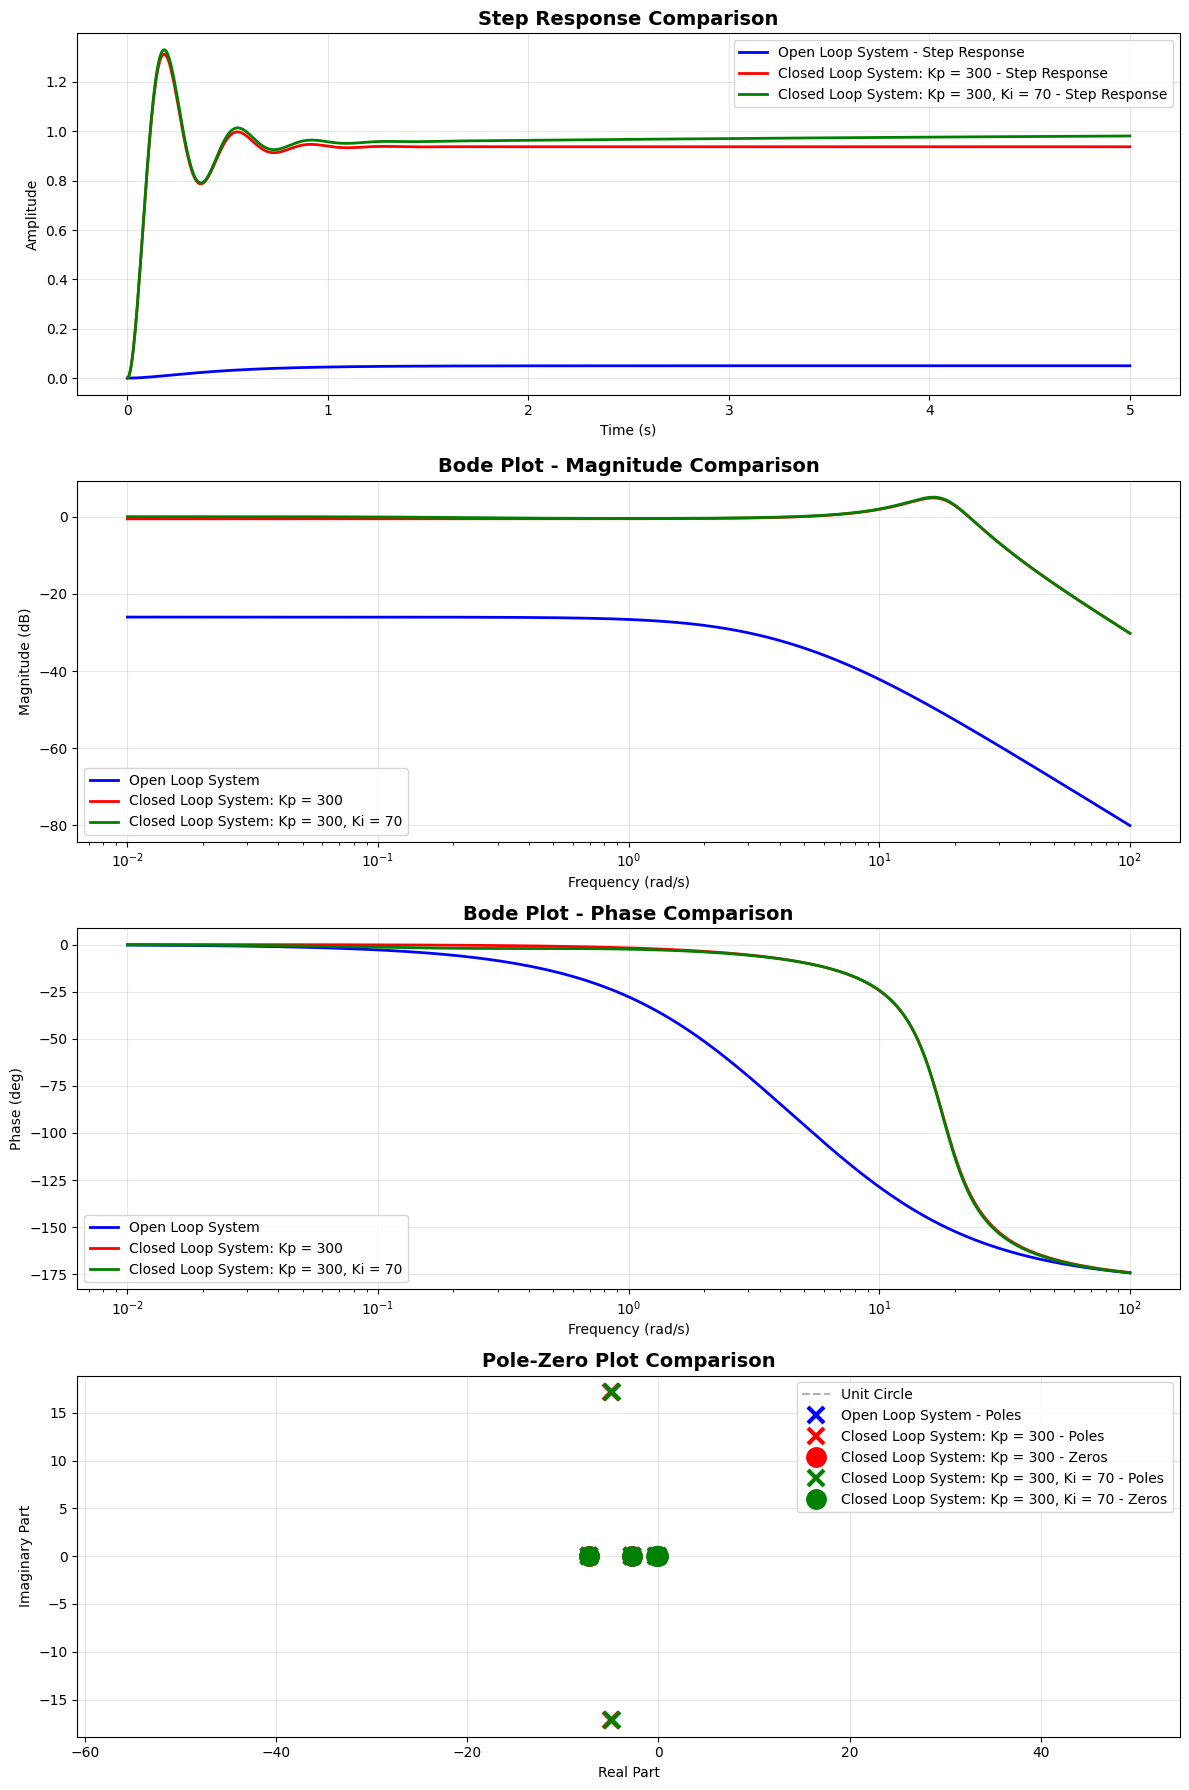

## Key System Parameters Comparison

| Parameter | Unit | Open Loop System | Closed Loop System: Kp = 300 | Closed Loop System: Kp = 300, Ki = 70 |
|-----------|------|------|------|------|
| **DC Gain (from step response)** | - | 0.0500 | 0.9375 | 0.9812 |
| **Rise Time** | s | 0.8809 | 0.0701 | 0.0751 |
| **Overshoot** | % | 0.00% | 40.04% | 35.61% |
| **Bandwidth (-3dB)** | rad/s | 2.457 | 26.268 | 25.788 |
| **Stability** | - | STABLE | STABLE | UNSTABLE |


In [206]:
# Closed loop response

controller_p_300 = create_pid(kp=300)
controller_p_300_i_70 = create_pid(kp=300, ki=70)

plant = open_loop_system

closed_loop_system_300 = controller_p_300 * plant / (1 + controller_p_300 * plant)
closed_loop_system_300_i_70 = controller_p_300_i_70 * plant / (1 + controller_p_300_i_70 * plant)

analyze_and_plot_transfer_function(
	{ 
		"Open Loop System": plant,
		"Closed Loop System: Kp = 300": closed_loop_system_300,
		"Closed Loop System: Kp = 300, Ki = 70": closed_loop_system_300_i_70
	},
	detailed=False
)